In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import argparse
import json
import sys
from sklearn import linear_model
import statsmodels.api as sm
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
#import shap
from scipy.interpolate import make_interp_spline

In [2]:
# Lectura de datos
## 2D

# Asignación de los argumentos a variables correspondientes
DATASET = 'chile'
# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../../data/data_people_dump_{DATASET}.csv')

dim_2 = pd.read_csv('../results/coordsU/chile_31_07_2024_10_54_23.csv')
dim_2 = pd.merge(userMetadata,dim_2,on='uuid')

**Se filtrará el autoreporte de politica de centro (5).**

In [3]:

dim_2 = dim_2[dim_2['politica']!=5].reset_index()
dim_2 = dim_2.drop('index',axis=1)


In [4]:
def label_region(region):
    """
    Define un identificador para las regiones
    """
    if region==0:
        return 0
    if region=='Arica y Parinacota':
        return 1
    elif region == 'Tarapacá':
        return 2
    elif region =='Antofagasta':
        return 3
    elif region =='Atacama':
        return 4
    elif region =='Coquimbo':
        return 5
    elif region =='Valparaíso':
        return 6
    elif region =='Metropolitana de Santiago' or region == 'Santiago Metropolitan':
        return 7
    elif region =="O'Higgins":
        return 8
    elif region =='Maule':
        return 9
    elif region =='Ñuble':
        return 10
    elif region =='Biobío' or region =='Biobio':
        return 11
    elif region =='Araucanía':
        return 12
    elif region =='Los Ríos':
        return 13
    elif region =='Los Lagos':
        return 14
    elif region =='Aysén':
        return 15
    elif region =='Magallanes':
        return 16
    elif region =='Outside of Chile' or region=='Fuera de Chile':
        return 17

# Se asigna un valor binario a la columna 'sex', reemplazando 'Femenino' con 0 y 'Masculino' con 1.
femenino = dim_2[dim_2['sex']=='Femenino'].index
dim_2['sex'] = 1
dim_2['sex'].iloc[femenino] = 0
dim_2['region'] = dim_2['region'].apply(lambda x:label_region(x))

## 2. Modelos de clasificación


**Los modelos de clasificación son herramientas esenciales para la automatización de decisiones basadas en datos en una variedad de campos, permitiendo la asignación precisa de elementos a categorías o clases.**

**En esta investigación, la categorización se establece de la siguiente manera:**

1. Categoría [0-4]: Izquierda
2. Categoría [6-10]: Derecha

**Además, también se realiza la clasificación en las siguientes categorías:**

1. Categoría [0, 1, 2]: Extrema Izquierda
2. Categoría [3, 4]: Izquierda
3. Categoría [6, 7]: Derecha
4. Categoría [8, 9, 10]: Extrema Derecha



In [5]:
# Definición de la función de etiquetado
def label(politica):
    """
    Asigna etiquetas a los valores de la variable 'politica' según ciertos rangos establecidos. 
    La etiqueta 0 representa [0,1,2] Extrema Izquierda
    La etiqueta 1 representa [3,4] Izquierda
    La etiqueta 2 representa [6,7] Derecha
    La etiqueta 3 representa [8,9,10] Extrema Derecha
    """
    if politica in [0, 1, 2]:
        label = 0
    elif politica in [3,4]:
        label = 1
    if politica in [6, 7]:
        label = 2
    elif politica in [8, 9, 10]:
        label = 3
    return label


dim_2['politica classifier'] = dim_2['politica'].apply(lambda x: label(x))

**Se divide la base de datos en train y test**

In [6]:
# Labels son los valores que queremos predecir
labels_4 = dim_2['politica classifier']
labels_4 = np.array(labels_4)


# axis 1 se refiere a las columnas
features = dim_2.drop(['id', 'politica', 'datetime', 'score', 'ip_hash', 'politica classifier'], axis=1)
feature_list = list(features.columns)
features = features.set_index('uuid')


# Dividimos los datos en conjuntos de entrenamiento y prueba
train_features_0, test_features_0, train_labels_4, test_labels_4 = train_test_split(features, labels_4, test_size=0.3, random_state=42)

train_features_1 = np.array(train_features_0)
test_features_1 = np.array(test_features_0)


# Escalado de características
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#scaler = StandardScaler()
train_features = scaler.fit_transform(train_features_1)
test_features = scaler.transform(test_features_1)
train_labels = [0 if x <= 1 else 1 for x in train_labels_4]
test_labels = [0 if x <= 1 else 1 for x in test_labels_4]


**2.1.4 Análisis** $z_1^2$, $z_2^2$, $z_1$ * $z_2$**coordenadas políticas (2d), edad, sexo y región (X) y auto reporte (Y: Izq-Der)**

In [7]:
""" Se añaden las coordenadas al cuadrado a la base de entrenamiento"""
# TRAIN
# Calcula las nuevas dimensiones
sexta_dimension = train_features_1[:, 3]**2
septima_dimension = train_features_1[:, 4]**2
octava_dimension = train_features_1[:, 3] * train_features_1[:, 4]

# Apila las nuevas dimensiones a la matriz original
new_train_features_1 = np.hstack((train_features_1, sexta_dimension.reshape(-1, 1), septima_dimension.reshape(-1, 1), octava_dimension.reshape(-1, 1)))

# TEST
# Calcula las nuevas dimensiones
sexta_dimension = test_features_1[:, 3]**2
septima_dimension = test_features_1[:, 4]**2
octava_dimension = test_features_1[:, 3] * test_features_1[:, 4]

# Apila las nuevas dimensiones a la matriz original
new_test_features_1 = np.hstack((test_features_1, sexta_dimension.reshape(-1, 1), septima_dimension.reshape(-1, 1), octava_dimension.reshape(-1, 1)))

scaler_1 = MinMaxScaler()
#scaler_1 = StandardScaler()
train_features_new = scaler_1.fit_transform(new_train_features_1)
test_features_new = scaler_1.transform(new_test_features_1)


### 2.2 Modelo de clasificación de Random Forest

**2.2.1 Análisis edad, sexo y región (X) y auto reporte (Y: Izq-Der)**

In [8]:
# Ajuste de la clasificación de Random Forest al conjunto de entrenamiento
model_socio = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)
model_socio.fit(train_features[:,0:3], train_labels)


# Predicción
y_pred_socio = model_socio.predict(test_features[:,0:3])


# Cálculo de recall y precision
precision = metrics.precision_score(test_labels, y_pred_socio,average='macro')
recall = metrics.recall_score(test_labels, y_pred_socio,average='macro')
f1_score= metrics.f1_score(test_labels, y_pred_socio,average='macro')
acc = metrics.accuracy_score(test_labels, y_pred_socio)



**2.2.1 Análisis coordenadas políticas (2d), edad, sexo y región (X) y auto reporte (Y: Izq-Der)**

In [9]:

# Ajuste de la clasificación de Random Forest al conjunto de entrenamiento
classifier = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)
classifier.fit(train_features, train_labels)

# Predicción de los resultados del conjunto de prueba
y_pred = classifier.predict(test_features)

# Cálculo de recall y precision
precision = metrics.precision_score(test_labels, y_pred,average='macro')
recall = metrics.recall_score(test_labels, y_pred,average='macro')
f1_score= metrics.f1_score(test_labels, y_pred,average='macro')
acc = metrics.accuracy_score(test_labels, y_pred)


print(acc)
#0.8209618400418192

0.839759190470091


In [10]:
# Obtener los árboles del bosque
estimators = classifier.estimators_

# Obtener la profundidad de cada árbol
depths = [estimator.tree_.max_depth for estimator in estimators]

# Imprimir la profundidad de cada árbol
for i, depth in enumerate(depths):
    print(f"Árbol {i+1}: Profundidad máxima = {depth}")

Árbol 1: Profundidad máxima = 40
Árbol 2: Profundidad máxima = 37
Árbol 3: Profundidad máxima = 35
Árbol 4: Profundidad máxima = 39
Árbol 5: Profundidad máxima = 34
Árbol 6: Profundidad máxima = 39
Árbol 7: Profundidad máxima = 43
Árbol 8: Profundidad máxima = 40
Árbol 9: Profundidad máxima = 40
Árbol 10: Profundidad máxima = 39
Árbol 11: Profundidad máxima = 38
Árbol 12: Profundidad máxima = 43
Árbol 13: Profundidad máxima = 37
Árbol 14: Profundidad máxima = 38
Árbol 15: Profundidad máxima = 37
Árbol 16: Profundidad máxima = 36
Árbol 17: Profundidad máxima = 45
Árbol 18: Profundidad máxima = 37
Árbol 19: Profundidad máxima = 43
Árbol 20: Profundidad máxima = 38
Árbol 21: Profundidad máxima = 36
Árbol 22: Profundidad máxima = 37
Árbol 23: Profundidad máxima = 36
Árbol 24: Profundidad máxima = 37
Árbol 25: Profundidad máxima = 50
Árbol 26: Profundidad máxima = 33
Árbol 27: Profundidad máxima = 36
Árbol 28: Profundidad máxima = 47
Árbol 29: Profundidad máxima = 37
Árbol 30: Profundidad m

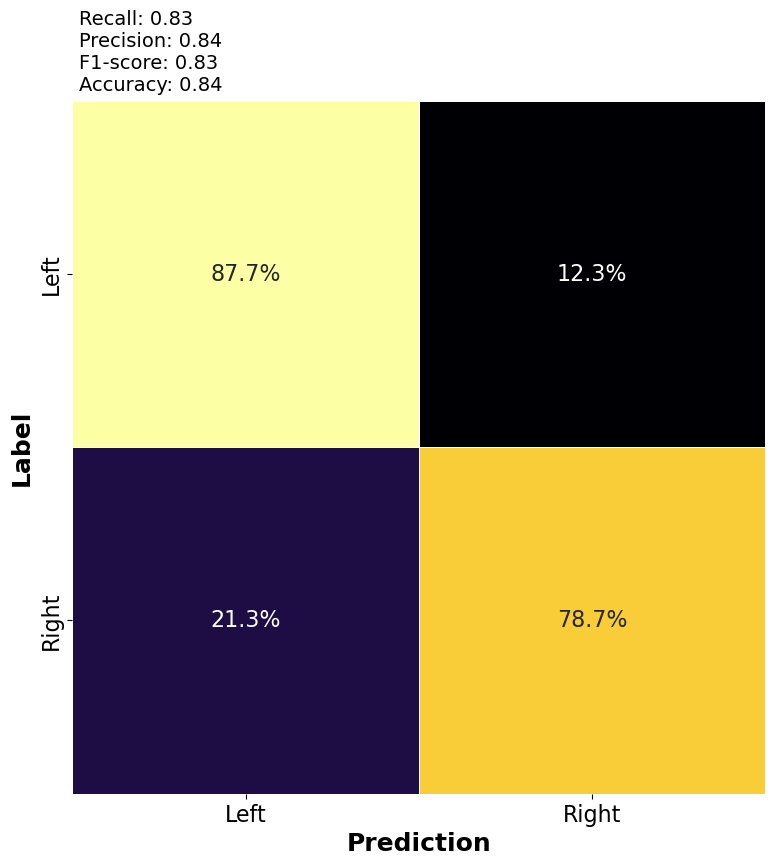

In [11]:
# Creación de la matriz de confusión
plt.figure(figsize=(9, 9))
matriz = confusion_matrix(test_labels, y_pred, normalize='true')
classes = ['Left', 'Right']
sns.heatmap(matriz, annot=True, fmt='.1%', linewidths=0.5, square=True, cmap='inferno', xticklabels=classes, yticklabels=classes, cbar=False,annot_kws={'size': 16})
plt.ylabel('Label', fontsize=18, fontweight='bold')
plt.xlabel('Prediction', fontsize=18, fontweight='bold')
all_sample_title = 'dim 2'
#plt.title(all_sample_title, size=15, fontweight='bold')


# Se imprimen métricas dentro de la figura con estilo "negrita"
metrics_text = f'Recall: {round(recall, 2)}\nPrecision: {round(precision, 2)}\nF1-score: {round(f1_score, 2)}\nAccuracy: {round(acc, 2)}'
plt.text(0.01, 1.07, metrics_text,  va='center', transform=plt.gca().transAxes, fontsize=14)

# Ajuste del tamaño de letra para las métricas
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Guardar la figura en la ruta 'figuras' con un título conveniente

plt.show()




In [19]:
# Export results
# Save the matrix as a file (e.g., .npz)
classes = ['Left', 'Right']
metrics = {'recall': recall, 'precision': precision, 'f1_score': f1_score, 'accuracy': acc}

np.savez("data_plots/confusion_matrix_data_Chile.npz", matriz=matriz, classes=classes, metrics=metrics)

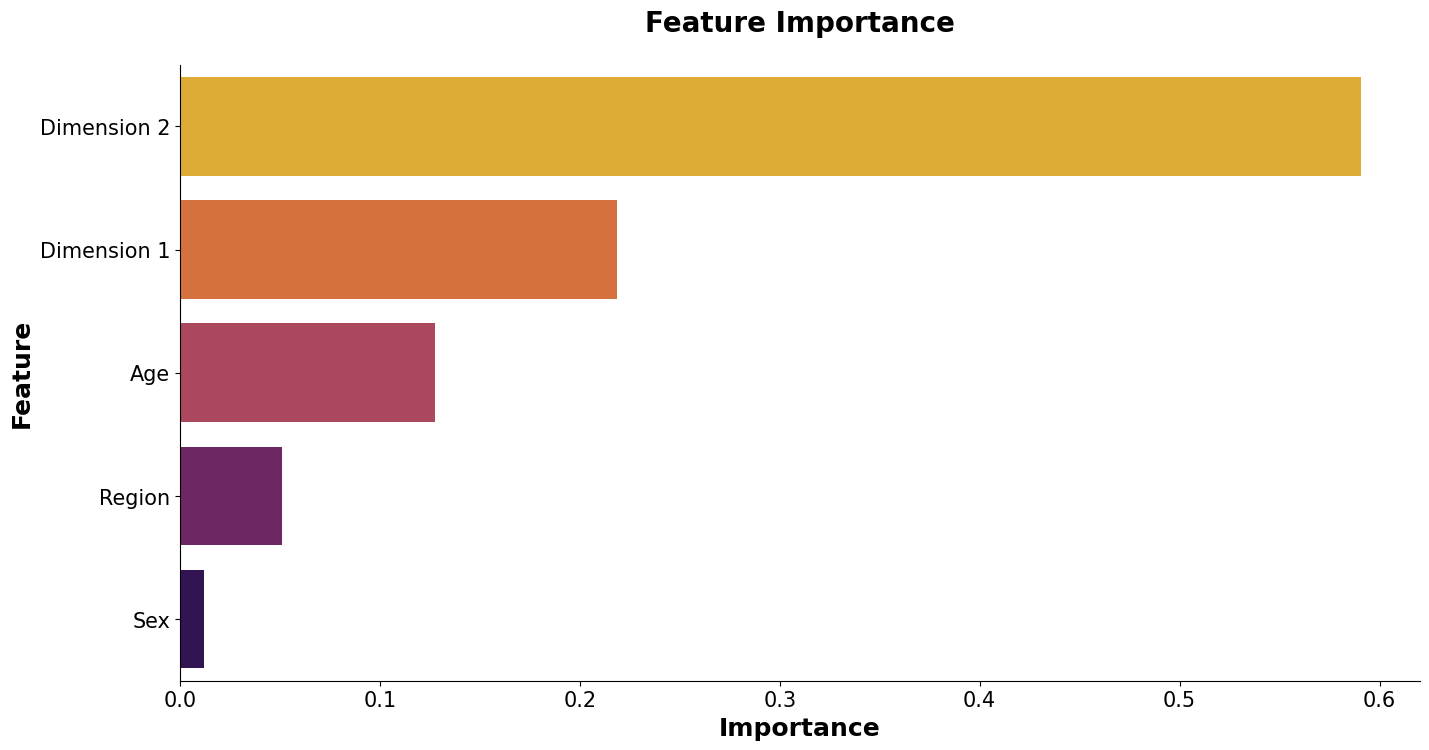

In [12]:
def hide_border(ax):
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


# Suponiendo que tienes tus datos de importancia de características y nombres de características
feature_importances = classifier.feature_importances_
feature_names = ['Sex', 'Age', 'Region', 'Dimension 2', 'Dimension 1']

# Obtener los índices ordenados de mayor a menor
sorted_indices = np.argsort(feature_importances)  # Orden descendente

# Reordenar los nombres de características y las importancias de características según los índices ordenados
sorted_feature_names = [feature_names[i] for i in sorted_indices]
sorted_feature_importances = [feature_importances[i] for i in sorted_indices]

# Crear un gráfico de barras para mostrar la importancia de las características ordenadas
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
colors = sns.color_palette('inferno', len(sorted_feature_importances))  # Obtener colores de la paleta 'inferno'
sns.barplot(y=sorted_feature_names, x=sorted_feature_importances, palette=colors, ax=ax)
plt.yticks(range(len(sorted_feature_importances)), sorted_feature_names, fontsize=15)
plt.xlabel('Importance', fontsize=18, fontweight='bold')
plt.ylabel('Feature', fontsize=18, fontweight='bold')
plt.setp(ax.get_xticklabels(), fontsize=15)
ax.set_title("Feature Importance", pad=24, fontweight=700, fontsize=20)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.gca().invert_yaxis()  # Invertir el eje y para que las características más importantes estén arriba
plt.show()


In [22]:
# Save the sorted feature importances to a CSV
export_data = pd.DataFrame({
    'Feature': sorted_feature_names,
    'Importance': sorted_feature_importances
})
export_data.to_csv('data_plots/feature_importance_chile.csv', index=False)

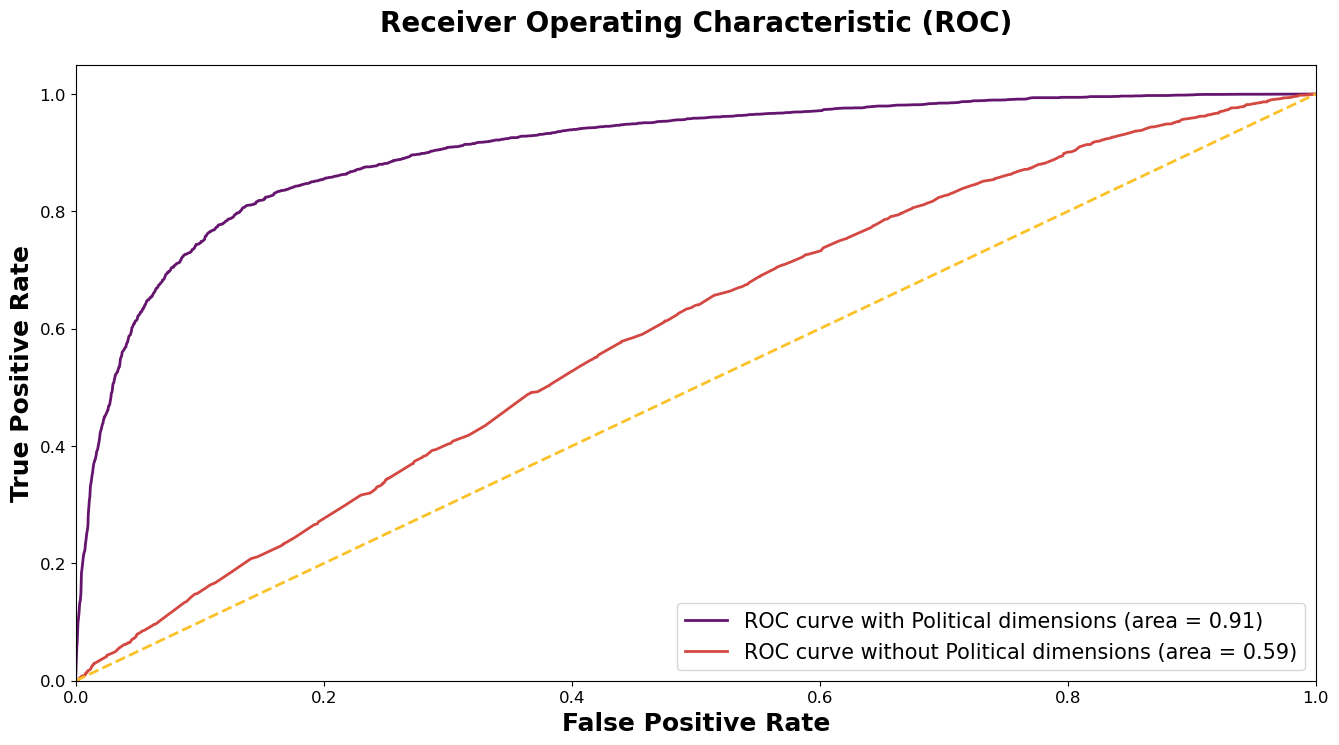

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Calcula la curva ROC
fpr_socio, tpr_socio, thresholds = roc_curve(test_labels, model_socio.predict_proba(test_features[:,0:3])[:,1])
roc_auc_socio = auc(fpr_socio, tpr_socio)


# Calcula la curva ROC
fpr, tpr, thresholds = roc_curve(test_labels, classifier.predict_proba(test_features)[:,1])
roc_auc = auc(fpr, tpr)

# Crear un gráfico de la curva ROC
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
sns.lineplot(x=fpr, y=tpr, color=sns.color_palette('inferno')[1], lw=2, label=f'ROC curve with Political dimensions (area = {roc_auc:.2f})')
sns.lineplot(x=fpr_socio, y=tpr_socio, color=sns.color_palette('inferno')[3], lw=2, label=f'ROC curve without Political dimensions (area = {roc_auc_socio:.2f})')

# Ajustes de la gráfica
plt.plot([0, 1], [0, 1], color=sns.color_palette('inferno')[5], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize = 19)
plt.yticks(fontsize = 19)
plt.xlabel('False Positive Rate', fontsize=18,fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=18,fontweight='bold')
ax.set_title("Receiver Operating Characteristic (ROC)", pad=24, fontweight=700, fontsize=20)
plt.legend(loc='lower right', fontsize=15)

# Aumentar el tamaño del texto
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('figuras/Plot/Receiver Operating Characteristic.png')
plt.show()


In [23]:
# Save ROC data with Political dimensions
roc_data = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr
})
roc_data.to_csv('data_plots/roc_with_political_chile.csv', index=False)

# Save ROC data without Political dimensions
roc_socio_data = pd.DataFrame({
    'FPR': fpr_socio,
    'TPR': tpr_socio
})
roc_socio_data.to_csv('data_plots/roc_without_political_chile.csv', index=False)

# Save AUC values
auc_data = pd.DataFrame({
    'Model': ['With Political Dimensions', 'Without Political Dimensions'],
    'AUC': [roc_auc, roc_auc_socio]
})
auc_data.to_csv('data_plots/roc_auc_values_chile.csv', index=False)


**Validación cruzada de 10 particiones**

In [14]:
from sklearn.model_selection import StratifiedKFold

# Definir el número de particiones
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Listas para almacenar los puntajes de validación cruzada y las predicciones
cv_scores = []
predictions = []
features = features.reset_index(drop=True)
a=0
for train_index, test_index in skf.split(features, labels_4):
    # Dividir los datos en entrenamiento y prueba
    X_train, X_test = features.iloc[train_index], features.iloc[test_index]
    y_train_fold, y_test_fold = labels_4[train_index], labels_4[test_index]

    # Escalar características
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    y_train_fold = [0 if x <= 1 else 1 for x in y_train_fold]
    y_test_fold = [0 if x <= 1 else 1 for x in y_test_fold]

    
    # Inicializar el clasificador y el escalador
    classifier = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)

    # Entrenar el clasificador
    classifier.fit(X_train_scaled, y_train_fold)

    # Calcular el puntaje de precisión en la partición de prueba
    test_predictions = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test_fold, test_predictions)
    cv_scores.append(accuracy)
    print(a)
    a=a+1


0
1
2
3
4
5
6
7
8
9


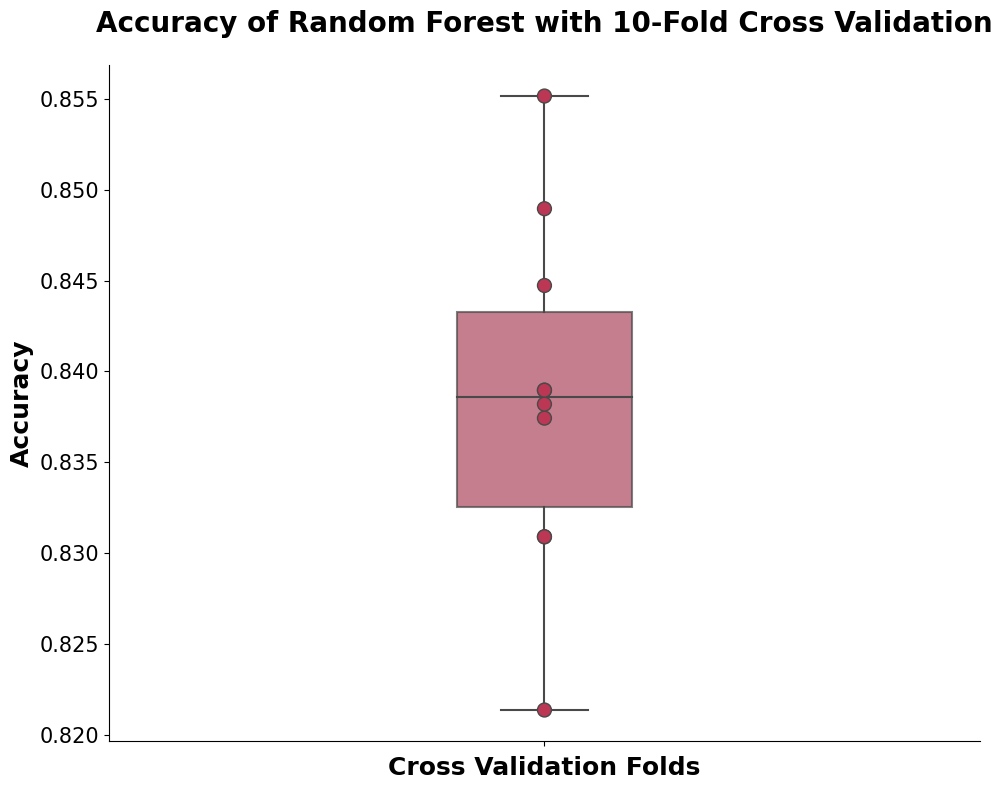

In [15]:

# Crear una figura
fig, ax = plt.subplots(1,1, figsize=(10,8))

# Plotear los resultados en un boxplot
sns.boxplot(y=cv_scores,palette='inferno',showfliers=False,ax=ax,boxprops={'alpha': 0.7},width = 0.2)
sns.stripplot(y=cv_scores,palette='inferno', dodge=True,ax=ax,size=10,jitter=0,linewidth=1)
#sns.boxplot(x=cv_scores, palette='viridis')
plt.yticks(fontsize = 15)
ax.set_xlabel('Cross Validation Folds',fontsize=18,fontweight='bold')
ax.set_ylabel('Accuracy',fontsize=18,fontweight='bold')
ax.set_title("Accuracy of Random Forest with 10-Fold Cross Validation",pad=24,fontweight=700,fontsize=20)
hide_border(ax)
# Mostrar la figura
plt.tight_layout()
#plt.savefig('figuras/Plot/Boxplot of SVM Accuracy with 10-Fold Cross Validation.png')
plt.show()

In [25]:
# Save cross-validation scores to a CSV file
cv_scores_df = pd.DataFrame({'CV_Scores': cv_scores})
cv_scores_df.to_csv('data_plots/cross_validation_scores_chile.csv', index=False)


In [20]:
# Creamos una instancia de RandomForestClassifier con los mejores parámetros encontrados
classifier = RandomForestClassifier(n_estimators=2000, criterion='entropy', random_state=42)

classifier.fit(train_features_new, train_labels)
# Predicción de los resultados del conjunto de prueba
y_pred = classifier.predict(test_features_new)

In [23]:
from sklearn import metrics  # Ensure this is correctly imported
# Cálculo de recall y precision
precision = metrics.precision_score(test_labels, y_pred,average='macro')
recall = metrics.recall_score(test_labels, y_pred,average='macro')
f1_score= metrics.f1_score(test_labels, y_pred,average='macro')
acc = metrics.accuracy_score(test_labels, y_pred)

**2.2.6 A continuación, procederemos a dividir el conjunto de pruebas en 10 particiones en función de la cantidad de votos considerando un análisis de** $z_1^2$, $z_2^2$, $z_1$ * $z_2$**coordenadas políticas (2d), edad, sexo y región (X) y auto reporte (Y: Izq-Der)****

  Votaciones  Precision    Recall  F1_score  Accuracy
0       2-19   0.800540  0.800143  0.797439  0.797445
1      20-20   0.792948  0.779892  0.782840  0.789062
2      21-25   0.797910  0.787130  0.791777  0.811460
3      26-37   0.809760  0.809389  0.809573  0.819216
4      38-54   0.831673  0.825509  0.828125  0.835000
5      55-79   0.856538  0.859541  0.857894  0.861635
6      80-98   0.865358  0.867535  0.866399  0.871944
7     99-133   0.847976  0.844376  0.845909  0.849252
8    134-384   0.882301  0.881544  0.881894  0.882812
9    385-725   0.917048  0.915385  0.916084  0.916667


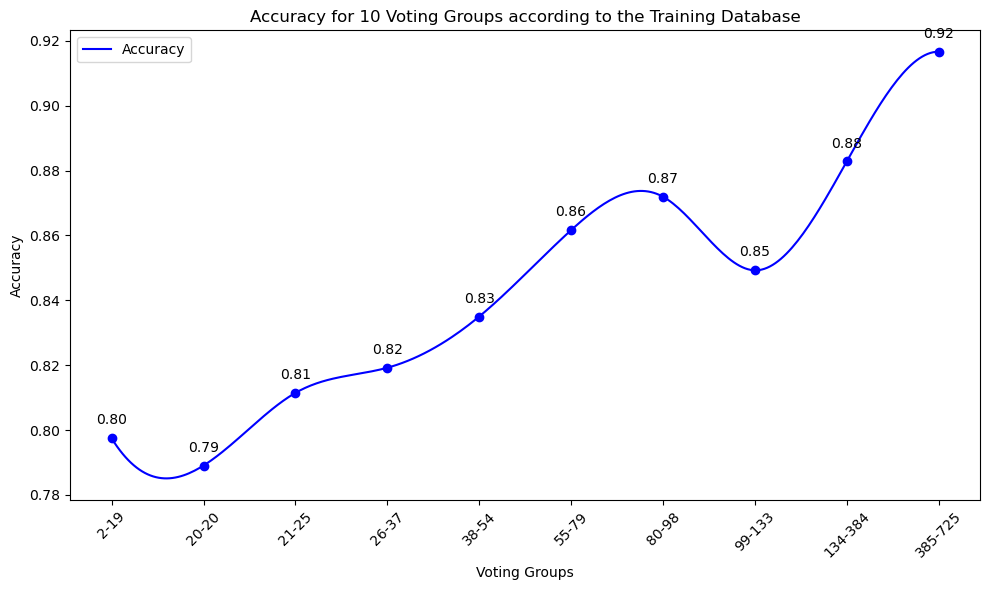

In [26]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from sklearn import metrics

# Load the JSON file containing the number of votes per user
with open('../results/cantidad_votaciones_usuarios_primerciclo.json', 'r') as archivo:
    datos = json.load(archivo)

# Create a DataFrame with user IDs and their vote counts
df_votaciones = pd.DataFrame(list(datos.items()), columns=['uuid', 'votaciones'])

# Merge with training and test datasets
df_completo_train = pd.merge(train_features_0, df_votaciones, on='uuid')
df_completo_test = pd.merge(test_features_0.reset_index().reset_index(), df_votaciones, on='uuid')

# Sort the training DataFrame by the number of votes
df_completo_train = df_completo_train.sort_values(by='votaciones')

# Compute percentiles for splitting into 10 groups
percentiles = np.percentile(df_completo_train['votaciones'], np.arange(0, 101, 11))

# Assign percentile group labels
df_completo_train['percentile_group'] = np.searchsorted(percentiles, df_completo_train['votaciones'], side='right') - 1

# Create separate DataFrames for each percentile group
grupos_por_percentil = [df_completo_train[df_completo_train['percentile_group'] == i] for i in range(len(percentiles))]

# Initialize list to store metrics
metricas = []

# Iterate over training data groups
for grupo in grupos_por_percentil:
    if grupo.empty:
        continue  # Skip empty groups
    
    cota_minima = grupo['votaciones'].min()
    cota_maxima = grupo['votaciones'].max()

    # Filter test data based on the vote count range
    test_features_grupo = df_completo_test[(df_completo_test['votaciones'] >= cota_minima) & 
                                           (df_completo_test['votaciones'] <= cota_maxima)]
    
    if test_features_grupo.empty:
        continue  # Skip empty test groups

    index = test_features_grupo['index'].to_list()
    y_pred_percentil = y_pred[index]
    test_labels_grupo = np.array(test_labels)[index]
    cotas = f"{int(cota_minima)}-{int(cota_maxima)}"

    # Compute classification metrics
    precision = metrics.precision_score(test_labels_grupo, y_pred_percentil, average='macro')
    recall = metrics.recall_score(test_labels_grupo, y_pred_percentil, average='macro')
    f1_score = metrics.f1_score(test_labels_grupo, y_pred_percentil, average='macro')
    acc = metrics.accuracy_score(test_labels_grupo, y_pred_percentil)

    # Store results
    metricas.append({'Votaciones': cotas, 'Precision': precision, 'Recall': recall, 'F1_score': f1_score, 'Accuracy': acc})

# Convert list to DataFrame
metricas = pd.DataFrame(metricas)

# Print metrics table
print(metricas)

# Create the accuracy plot
plt.figure(figsize=(10, 6))

# Interpolate the accuracy curve for smooth visualization
xnew = np.linspace(0, len(metricas['Accuracy']) - 1, 300)
spl = make_interp_spline(range(len(metricas['Accuracy'])), metricas['Accuracy'], k=3)
y_smooth = spl(xnew)

# Plot smoothed accuracy curve
plt.plot(xnew, y_smooth, label='Accuracy', color='blue')

# Plot actual data points
plt.scatter(range(len(metricas['Accuracy'])), metricas['Accuracy'], color='blue', marker='o')

# Annotate accuracy values on the points
for i, txt in enumerate(metricas['Accuracy']):
    plt.annotate(f'{txt:.2f}', (i, txt), textcoords="offset points", xytext=(0, 10), ha='center')

# Set x-axis labels
plt.xticks(range(len(metricas)), metricas['Votaciones'], rotation=45)
plt.xlabel("Voting Groups")
plt.ylabel('Accuracy')
plt.title("Accuracy for 10 Voting Groups according to the Training Database")

plt.legend()
plt.tight_layout()
plt.show()


In [27]:
# Save the relevant columns to CSV
metricas[['Votaciones', 'Accuracy']].to_csv("data_plots/Groups_Accuracy_Chile.csv", index=False)
print("CSV file saved at data_plots/Groups_Accuracy.csv")

CSV file saved at data_plots/Groups_Accuracy.csv


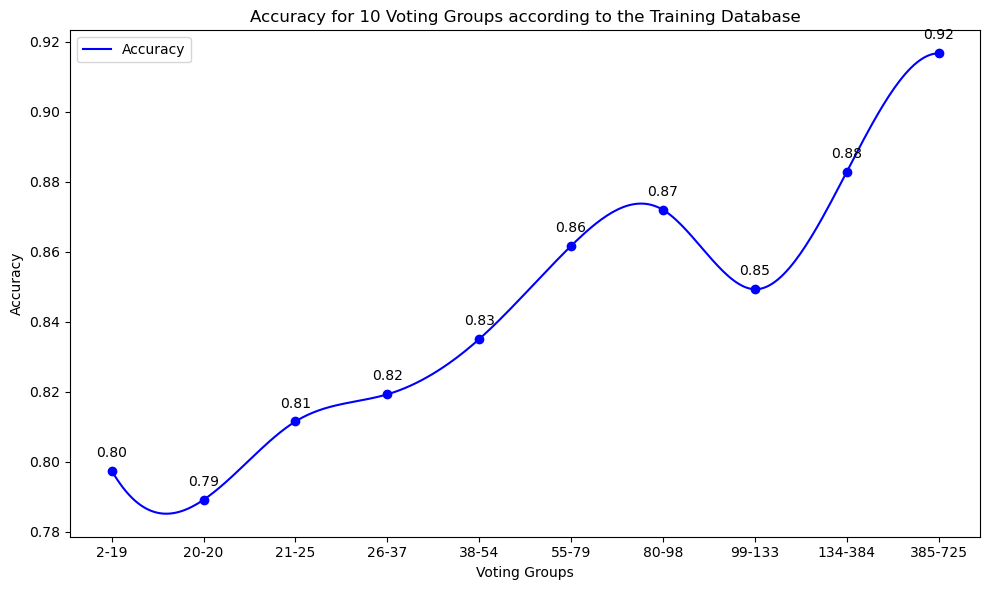

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Load the CSV file
df = pd.read_csv("data_plots/Groups_Accuracy_Chile.csv")

# Ensure data consistency
if df.isnull().values.any():
    raise ValueError("The CSV contains missing values, check the data integrity.")

# Generate the X-axis
x_values = range(len(df['Accuracy']))

# Smooth the curve using interpolation
xnew = np.linspace(0, len(df['Accuracy']) - 1, 300)
spl = make_interp_spline(x_values, df['Accuracy'], k=3)
y_smooth = spl(xnew)

# Plot the accuracy
plt.figure(figsize=(10, 6))
plt.plot(xnew, y_smooth, label='Accuracy', color='blue')

# Add scatter points
plt.scatter(x_values, df['Accuracy'], color='blue', marker='o')

# Annotate each point with its accuracy value
for i, txt in enumerate(df['Accuracy']):
    plt.annotate(f'{txt:.2f}', (i, txt), textcoords="offset points", xytext=(0, 10), ha='center')

plt.xticks(x_values, df['Votaciones'])  # Set X-axis labels
plt.xlabel("Voting Groups")
plt.ylabel("Accuracy")
plt.title("Accuracy for 10 Voting Groups according to the Training Database")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()